<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Домашнее задание. Обучение языковой модели с помощью LSTM (10 баллов)

В этом задании Вам предстоит обучить языковую модель с помощью рекуррентной нейронной сети. В отличие от семинарского занятия, Вам необходимо будет работать с отдельными словами, а не буквами.


Установим модуль ```datasets```, чтобы нам проще было работать с данными.

In [1]:
!pip install datasets

Импорт необходимых библиотек

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List

import seaborn
seaborn.set(palette='summer')

In [3]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [4]:
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
device = 'cpu'
device

'cpu'

## Подготовка данных

Воспользуемся датасетом imdb. В нем хранятся отзывы о фильмах с сайта imdb. Загрузим данные с помощью функции ```load_dataset```

In [5]:
# Загрузим датасет
dataset = load_dataset('imdb')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

### Препроцессинг данных и создание словаря (1 балл)

Далее вам необходмо самостоятельно произвести препроцессинг данных и получить словарь или же просто ```set``` строк. Что необходимо сделать:

1. Разделить отдельные тренировочные примеры на отдельные предложения с помощью функции ```sent_tokenize``` из бибилиотеки ```nltk```. Каждое отдельное предложение будет одним тренировочным примером.
2. Оставить только те предложения, в которых меньше ```word_threshold``` слов.
3. Посчитать частоту вхождения каждого слова в оставшихся предложениях. Для деления предлоения на отдельные слова удобно использовать функцию ```word_tokenize```.
4. Создать объект ```vocab``` класса ```set```, положить в него служебные токены '\<unk\>', '\<bos\>', '\<eos\>', '\<pad\>' и vocab_size самых частовстречающихся слов.   

In [7]:
sentences = []
word_threshold = 32

# Получить отдельные предложения и поместить их в sentences
for sentence in tqdm(dataset['train']['text']):
  sentences.extend(
      [x.lower() for x in sent_tokenize(sentence, language='russian') if len(x) < 32]
  )

  0%|          | 0/25000 [00:00<?, ?it/s]

In [ ]:
print("Всего предложений:", len(sentences))

Всего предложений: 29983


пояснение: ограничен ресурс на GPU, в данном дз взята только train выборка из датасета

Посчитаем для каждого слова его встречаемость.

In [8]:
words = Counter()
count_words = []

# Расчет встречаемости слов
for sentence in tqdm(sentences):
  count_words = [x.lower() for x in word_tokenize(sentence, language="russian")]
  for word in count_words:
    words[word] += 1

  0%|          | 0/29983 [00:00<?, ?it/s]

In [9]:
len(words)

10154

Добавим в словарь ```vocab_size``` самых встречающихся слов.

In [10]:
vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
vocab_size = 10025

most_common = words.most_common(vocab_size)
for word, _ in most_common:
    vocab.add(word)

In [ ]:
assert '<unk>' in vocab
assert '<bos>' in vocab
assert '<eos>' in vocab
assert '<pad>' in vocab
assert len(vocab) == vocab_size + 4

In [11]:
print("Всего слов в словаре:", len(vocab))

Всего слов в словаре: 10029


In [12]:
vocab_size = len(vocab)

### Подготовка датасета (1 балл)

Далее, как и в семинарском занятии, подготовим датасеты и даталоадеры.

В классе ```WordDataset``` вам необходимо реализовать метод ```__getitem__```, который будет возвращать сэмпл данных по входному idx, то есть список целых чисел (индексов слов).

Внутри этого метода необходимо добавить служебные токены начала и конца последовательности, а также токенизировать соответствующее предложение с помощью ```word_tokenize``` и сопоставить ему индексы из ```word2ind```.

In [14]:
word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

In [17]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        tokenized_sentence = [self.bos_id]
        tokenized_sentence += [word2ind.get(word, self.unk_id) for word in self.data[idx]]
        tokenized_sentence += [self.eos_id]

        return tokenized_sentence

    def __len__(self) -> int:
        return len(self.data)

In [15]:
def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>']) -> torch.Tensor:
    seq_lens = [len(x) for x in input_batch]
    max_seq_len = max(seq_lens)

    new_batch = []
    for sequence in input_batch:
        for _ in range(max_seq_len - len(sequence)):
            sequence.append(pad_id)
        new_batch.append(sequence)

    sequences = torch.LongTensor(new_batch).to(device)

    new_batch = {
        'input_ids': sequences[:,:-1], # все кроме последнего токена
    'target_ids': sequences[:,1:]     # все кроме первого токена
    }

    return new_batch

In [18]:
train_sentences, eval_sentences = train_test_split(sentences, test_size=0.2)
eval_sentences, test_sentences = train_test_split(sentences, test_size=0.5)

train_dataset = WordDataset(train_sentences)
eval_dataset = WordDataset(eval_sentences)
test_dataset = WordDataset(test_sentences)

batch_size = 128

train_dataloader = DataLoader(
    train_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

test_dataloader = DataLoader(
    test_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

## Обучение и архитектура модели

Вам необходимо на практике проверить, что влияет на качество языковых моделей. В этом задании нужно провести серию экспериментов с различными вариантами языковых моделей и сравнить различия в конечной перплексии на тестовом множестве.

Возмоэные идеи для экспериментов:

* Различные RNN-блоки, например, LSTM или GRU. Также можно добавить сразу несколько RNN блоков друг над другом с помощью аргумента num_layers. Вам поможет официальная документация [здесь](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
* Различные размеры скрытого состояния. Различное количество линейных слоев после RNN-блока. Различные функции активации.
* Добавление нормализаций в виде Dropout, BatchNorm или LayerNorm
* Различные аргументы для оптимизации, например, подбор оптимального learning rate или тип алгоритма оптимизации SGD, Adam, RMSProp и другие
* Любые другие идеи и подходы

После проведения экспериментов необходимо составить таблицу результатов, в которой описан каждый эксперимент и посчитана перплексия на тестовом множестве.

Учтите, что эксперименты, которые различаются, например, только размером скрытого состояния или количеством линейных слоев считаются, как один эксперимент.

Успехов!

### Функция evaluate (1 балл)

Заполните функцию ```evaluate```

In [ ]:
def evaluate(model, criterion, dataloader) -> float:
    model.eval()
    perplexity = []
    with torch.no_grad():
        for batch in dataloader:
            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
            loss = criterion(logits, batch['target_ids'].flatten())
            perplexity.append(torch.exp(loss).item())

    perplexity = sum(perplexity) / len(perplexity)

    return perplexity

### Train loop (1 балл)

Напишите функцию для обучения модели.

In [ ]:
def train_model(train_dataloader, model, optimizer, criterion, num_epoch=10):
    # Напишите код здесь
    losses = []
    perplexities = []

    for epoch in range(num_epoch):
      epoch_losses = []
      model.train()
      for batch in tqdm(train_dataloader, desc=f'Training epoch {epoch}'):
        optimizer.zero_grad()
        logits = model(batch['input_ids'])  # (batch, seq_len, vocab_size)
        logits = logits.reshape(-1, logits.size(-1))  # (batch*seq_len, vocab_size)
        targets = batch['target_ids'].reshape(-1)  # (batch*seq_len)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())

      losses.append(sum(epoch_losses) / len(epoch_losses))
      perplexities.append(evaluate(model, criterion, train_dataloader))

    return losses, perplexities

### Первый эксперимент (2 балла): GRU

Определите архитектуру модели и обучите её.

In [ ]:
class GRU(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)
        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        # А тут опишите forward pass модели
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = self.dropout(self.linear(self.non_lin(output)))
        projection = self.projection(self.non_lin(output))

        return projection

In [ ]:
from torch.optim import SGD

# Обучите модель здесь
model = GRU(hidden_dim=256, vocab_size=10029)
optimizer = SGD(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()
losses, perplexities = train_model(train_dataloader, model, optimizer, criterion)

Training epoch 0:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 1:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 2:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 3:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 4:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 5:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 6:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 7:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 8:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 9:   0%|          | 0/188 [00:00<?, ?it/s]

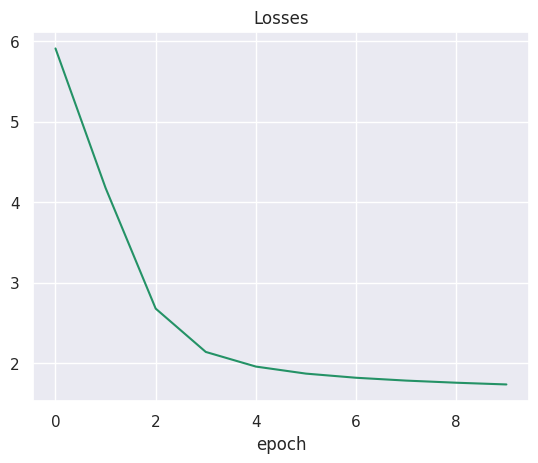

In [ ]:
plt.plot(np.arange(len(losses)), losses)
plt.title('Losses')
plt.xlabel("epoch")
plt.show()

пояснение: loss падает и достигает показателя около 1.7 к 10 эпохе

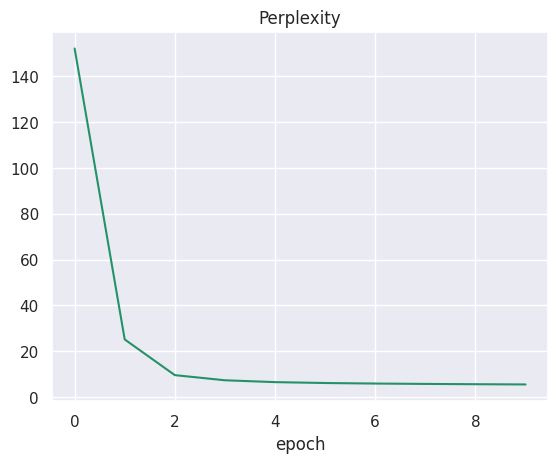

In [ ]:
plt.plot(np.arange(len(perplexities)), perplexities)
plt.title('Perplexity')
plt.xlabel("epoch")
plt.show()

пояснение: perplexity падает довольно быстро и достигает показателя около 7 к 6 эпохе и после не меняется

### Второй эксперимент (2 балла): замена на LSTM

Попробуйте что-то поменять в модели или в пайплайне обучения, идеи для экспериментов можно подсмотреть выше.

In [ ]:
# Проведите второй эксперимент
class LSTM(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)
        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        # А тут опишите forward pass модели
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = self.dropout(self.linear(self.non_lin(output)))
        projection = self.projection(self.non_lin(output))

        return projection

In [ ]:
from torch.optim import SGD

# Обучите модель здесь
model = LSTM(hidden_dim=256, vocab_size=10029)
optimizer = SGD(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()
losses, perplexities = train_model(train_dataloader, model, optimizer, criterion)

Training epoch 0:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 1:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 2:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 3:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 4:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 5:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 6:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 7:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 8:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 9:   0%|          | 0/188 [00:00<?, ?it/s]

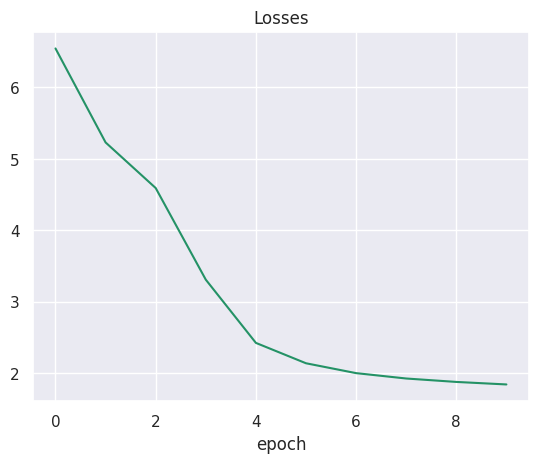

In [ ]:
plt.plot(np.arange(len(losses)), losses)
plt.title('Losses')
plt.xlabel("epoch")
plt.show()

пояснение: loss падает несколько неравномерно и достигает показателя 1.8 к 10 эпохе

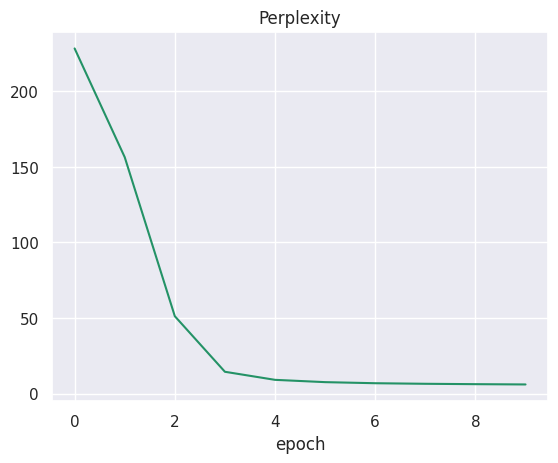

In [ ]:
plt.plot(np.arange(len(perplexities)), perplexities)
plt.title('Perplexity')
plt.xlabel("epoch")
plt.show()

пояснение: perplexity падает c изначально более высоких значений (> 200) несколько неравномерно и достигает показателя около 9 к 6  эпохе и больше не меняется

### Третий эксперимент: замена SGD на Adam

In [ ]:
from torch.optim import Adam

# Обучите модель здесь
model = LSTM(hidden_dim=256, vocab_size=10029)
optimizer = Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()
losses, perplexities = train_model(train_dataloader, model, optimizer, criterion)

Training epoch 0:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 1:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 2:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 3:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 4:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 5:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 6:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 7:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 8:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 9:   0%|          | 0/188 [00:00<?, ?it/s]

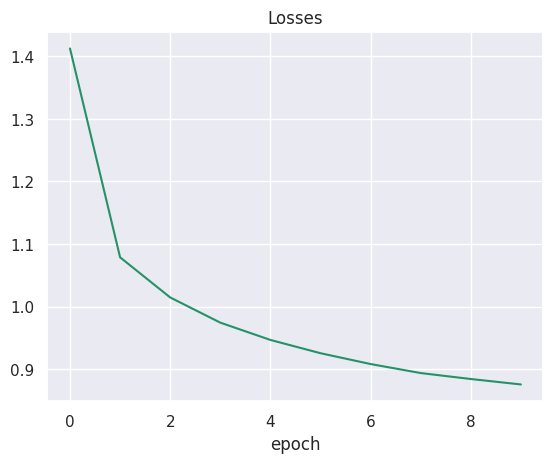

In [ ]:
plt.plot(np.arange(len(losses)), losses)
plt.title('Losses')
plt.xlabel("epoch")
plt.show()

пояснение: loss падает и достигает показателя < 0.9 к 10 эпохе, что в 2 раза лучший показатель, чем у SGD

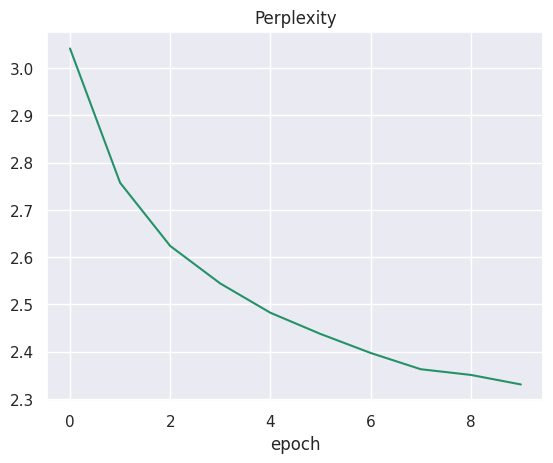

In [ ]:
plt.plot(np.arange(len(perplexities)), perplexities)
plt.title('Perplexity')
plt.xlabel("epoch")
plt.show()

пояснение: perplexity падает плавно и достигает показателя около 2.34 к 10 эпохе, возможно стоило продолжить обучение на большем количестве эпох для достижения лучших показателей

### Четвертый эксперимент: оптимизатор RMSProp

In [ ]:
from torch.optim import RMSprop

# Обучите модель здесь
model = LSTM(hidden_dim=256, vocab_size=10029)
optimizer = RMSprop(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()
losses, perplexities = train_model(train_dataloader, model, optimizer, criterion)

Training epoch 0:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 1:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 2:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 3:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 4:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 5:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 6:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 7:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 8:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 9:   0%|          | 0/188 [00:00<?, ?it/s]

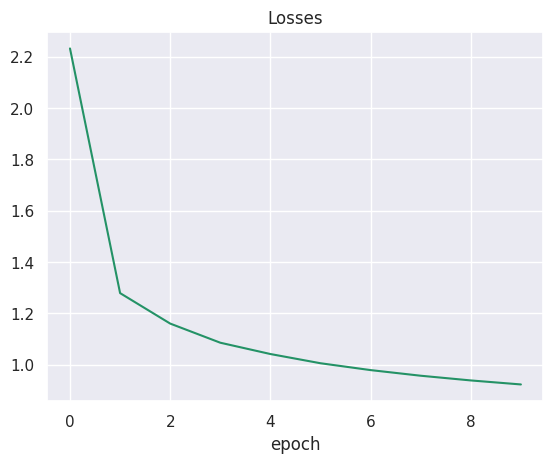

In [ ]:
plt.plot(np.arange(len(losses)), losses)
plt.title('Losses')
plt.xlabel("epoch")
plt.show()

In [ ]:
пояснение: loss падает довольно быстро и достигает показателя (0.9 < loss < 1.0) к 10 эпохе, возможно стоило продолжить обучение на большем количестве эпох для достижения лучших показателей

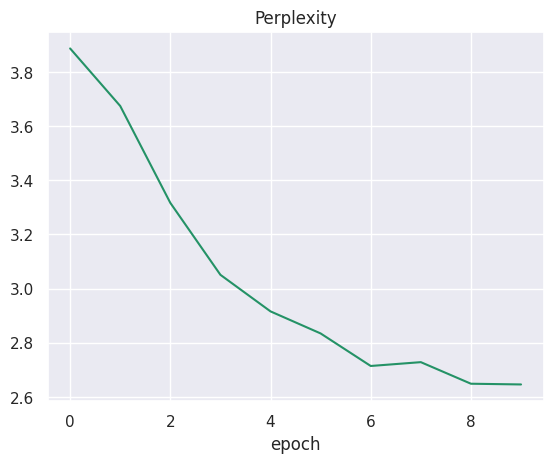

In [ ]:
plt.plot(np.arange(len(perplexities)), perplexities)
plt.title('Perplexity')
plt.xlabel("epoch")
plt.show()

пояснение: perplexity падает несколько неравномерно и достигает показателя < 2.7 к 10 эпохе

###  Пятый эксперимент: BiLSTM

In [ ]:
class BiLSTM(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.LSTM(hidden_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.linear = nn.Linear(hidden_dim * 2, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)
        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        # А тут опишите forward pass модели
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = self.dropout(self.linear(self.non_lin(output)))
        projection = self.projection(self.non_lin(output))

        return projection

In [ ]:
from torch.optim import Adam

# Обучите модель здесь
model = BiLSTM(hidden_dim=256, vocab_size=10029)
optimizer = Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()
losses, perplexities = train_model(train_dataloader, model, optimizer, criterion)

Training epoch 0:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 1:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 2:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 3:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 4:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 5:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 6:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 7:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 8:   0%|          | 0/188 [00:00<?, ?it/s]

Training epoch 9:   0%|          | 0/188 [00:00<?, ?it/s]

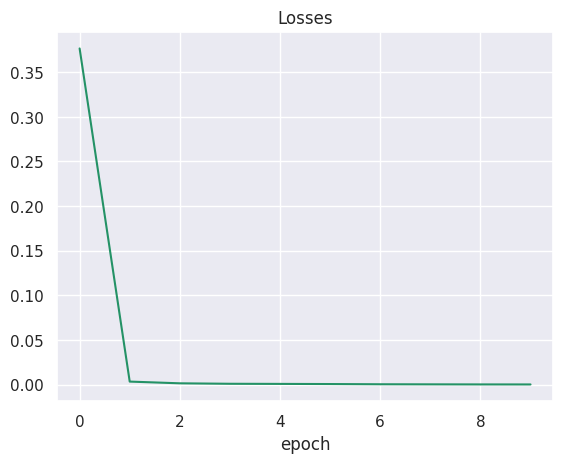

In [ ]:
plt.plot(np.arange(len(losses)), losses)
plt.title('Losses')
plt.xlabel("epoch")
plt.show()

In [ ]:
пояснение: loss падает очень быстро и достигает 0 ко 2 эпохе

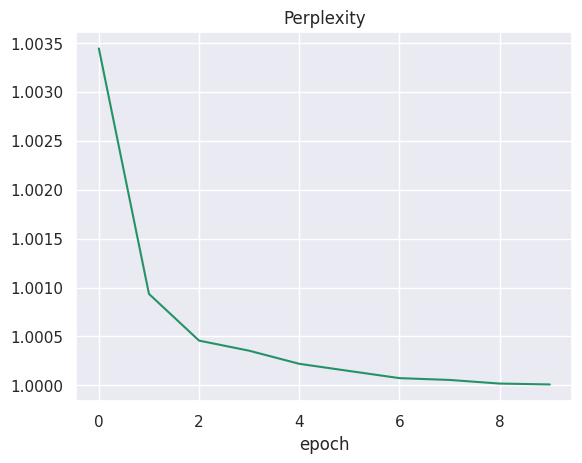

In [ ]:
plt.plot(np.arange(len(perplexities)), perplexities)
plt.title('Perplexity')
plt.xlabel("epoch")
plt.show()

пояснение: perplexity падает довольно быстро и достигает 1 к 10 эпохе, что является лучшим результатом

### Отчет (2 балла)

Опишите проведенные эксперименты. Сравните перплексии полученных моделей. Предложите идеи по улучшению качества моделей.

1. GRU + SGD - датасет небольшой -> GRU может работать лучше LSTM

loss: 1.7

perplexity: 7.0

2. LSTM + SGD

loss: 1.8

perplexity: 9.0


3. LSTM + Adam - лучший результат (возможно стоило попробовать комбинацию GRU + Adam)

loss: 0.88

perplexity: 2.34


4. LSTM + RMSProp

loss: 0.95

perplexity: 2.7


5. BiLSTM - переобучение вследствие небольшой выборки и высокой способности LSTM к запоминанию (в попытке найти более сложные зависимости)

loss: 0.0

perplexity: 1.0


**Выводы:**

- Adam является лучшим оптимизатором

- GRU показывает немного лучшие результаты, чем LSTM

- на BiLSTM + Adam переобучение

- LSTM + Adam - лучший результат